In [2]:
import pandas as pd

df = pd.read_csv("../data/historical/2026-06.csv")

print("Rows and Columns:", df.shape)
print()
print(df.dtypes)
df.head()

Rows and Columns: (606511, 15)

system_id                  str
last_reported              str
station_id               int64
num_bikes_available      int64
num_docks_available      int64
is_installed              bool
is_renting                bool
is_returning              bool
name                       str
short_name             float64
address                    str
lat                    float64
lon                    float64
region_id              float64
capacity                 int64
dtype: object


,system_id,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,short_name,address,lat,lon,region_id,capacity
0,dublin_bikes,2026-06-01 00:05:00,1,20,11,True,True,True,CLARENDON ROW,NaN,Clarendon Row,53.340927,-6.262501,NaN,31
1,dublin_bikes,2026-06-01 00:05:00,10,15,1,True,True,True,DAME STREET,NaN,Dame Street,53.344006,-6.266802,NaN,16
2,dublin_bikes,2026-06-01 00:05:00,101,6,24,True,True,True,KING STREET NORTH,NaN,King Street North,53.350292,-6.273507,NaN,30
3,dublin_bikes,2026-06-01 00:05:00,107,8,32,True,True,True,CHARLEVILLE ROAD,NaN,Charleville Road,53.359158,-6.281866,NaN,40
4,dublin_bikes,2026-06-01 00:05:00,109,23,6,True,True,True,BUCKINGHAM STREET LOWER,NaN,Buckingham Street Lower,53.353333,-6.249319,NaN,29


In [3]:
# Turn the time text into real date-times, in Dublin local time
df["last_reported"] = pd.to_datetime(df["last_reported"], utc=True).dt.tz_convert("Europe/Dublin")

# Remove columns we don't need
df = df.drop(columns=["system_id", "short_name", "region_id"])

# Keep only stations that were working and have docks
df = df[df["is_installed"] & df["is_renting"] & (df["capacity"] > 0)]

print("From:", df["last_reported"].min())
print("To:  ", df["last_reported"].max())
print("Stations:", df["station_id"].nunique())
print("Rows after cleaning:", len(df))
print("Duplicate readings:", df.duplicated(["station_id", "last_reported"]).sum())
print()
print("Missing values:")
print(df.isna().sum())

From: 2026-06-01 01:05:00+01:00
To:   2026-07-01 00:55:00+01:00
Stations: 115
Rows after cleaning: 606510
Duplicate readings: 0

Missing values:
last_reported          0
station_id             0
num_bikes_available    0
num_docks_available    0
is_installed           0
is_renting             0
is_returning           0
name                   0
address                0
lat                    0
lon                    0
capacity               0
dtype: int64


In [4]:
df = df.sort_values(["station_id", "last_reported"])
gaps = df.groupby("station_id")["last_reported"].diff()
print(gaps.describe())

count                    606395
mean     0 days 00:08:09.304826
std      0 days 00:06:52.161321
min             0 days 00:05:00
25%             0 days 00:05:00
50%             0 days 00:10:00
75%             0 days 00:10:00
max             0 days 10:50:00
Name: last_reported, dtype: object


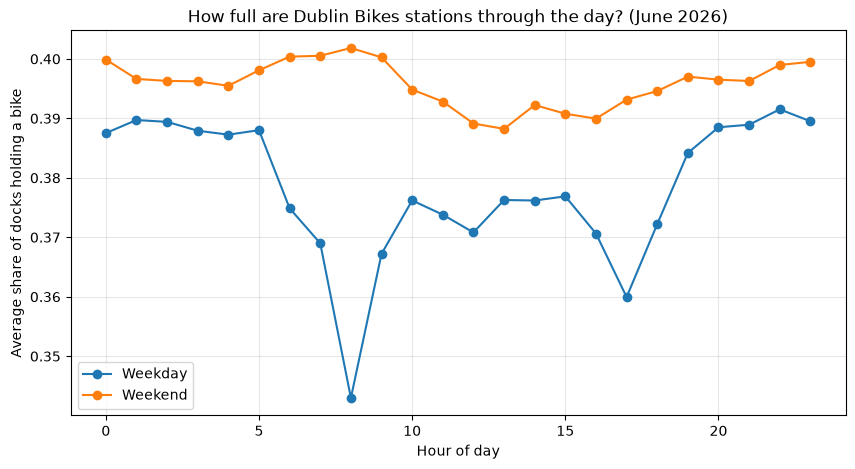

In [5]:
import matplotlib.pyplot as plt

df["hour"] = df["last_reported"].dt.hour
df["is_weekend"] = df["last_reported"].dt.dayofweek >= 5
df["fill_ratio"] = df["num_bikes_available"] / df["capacity"]

hourly = df.groupby(["hour", "is_weekend"])["fill_ratio"].mean().unstack()
hourly.columns = ["Weekday", "Weekend"]

hourly.plot(figsize=(10, 5), marker="o")
plt.title("How full are Dublin Bikes stations through the day? (June 2026)")
plt.xlabel("Hour of day")
plt.ylabel("Average share of docks holding a bike")
plt.grid(alpha=0.3)
plt.show()

In [6]:
df["is_empty"] = df["num_bikes_available"] == 0
empty_share = df.groupby("name")["is_empty"].mean().sort_values(ascending=False)

print("% of the time each station had zero bikes (top 10):")
print((empty_share.head(10) * 100).round(1))

% of the time each station had zero bikes (top 10):
name
PARNELL SQUARE NORTH            47.3
HARDWICKE PLACE                 40.0
ECCLES STREET EAST              35.7
FITZWILLIAM SQUARE EAST         31.5
GRANGEGORMAN LOWER (CENTRAL)    30.5
HERBERT STREET                  29.9
JAMES STREET EAST               27.0
HANOVER QUAY EAST               25.5
ECCLES STREET                   24.8
EARLSFORT TERRACE               23.6
Name: is_empty, dtype: float64


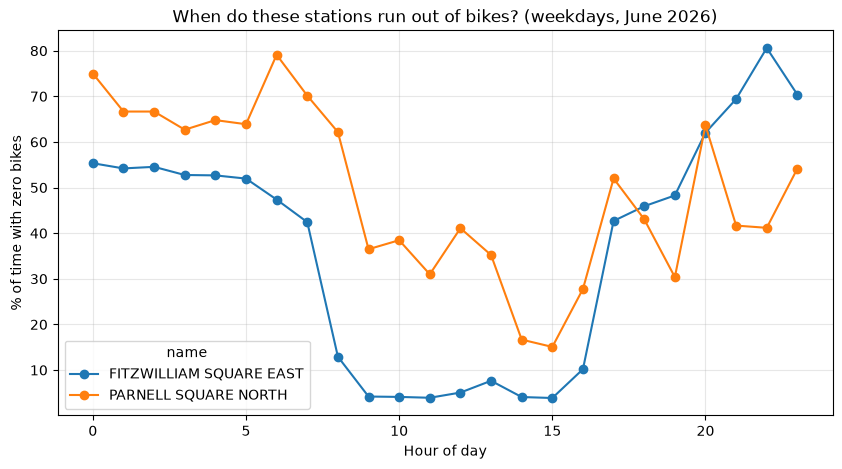

In [7]:
stations = ["PARNELL SQUARE NORTH", "FITZWILLIAM SQUARE EAST"]
weekday = df[~df["is_weekend"] & df["name"].isin(stations)]

pattern = weekday.groupby(["hour", "name"])["is_empty"].mean().unstack() * 100

pattern.plot(figsize=(10, 5), marker="o")
plt.title("When do these stations run out of bikes? (weekdays, June 2026)")
plt.xlabel("Hour of day")
plt.ylabel("% of time with zero bikes")
plt.grid(alpha=0.3)
plt.show()